# Tuần 03 — Tóm tắt dữ liệu (2/3): Ngữ pháp đồ họa và Điều kiện hóa

**UET.MAT1052 — Xác suất thống kê**
ThS. Hoàng Hữu Bách — BM. Khoa học & Kỹ thuật tính toán - Khoa Công nghệ Thông tin, VNU-UET

---

Tuần trước ta đã dùng khá nhiều loại biểu đồ: cột, histogram, hộp, chấm, mật độ, violin. Mỗi loại được giới thiệu như một công cụ riêng. Tuần này đặt câu hỏi ngược lại: **có một cấu trúc chung nào nằm sau tất cả các biểu đồ đó không?** Có, và khi đã nhìn ra cấu trúc ấy, bạn sẽ đọc được, sửa được, và tự thiết kế được biểu đồ thay vì chọn theo thói quen.

Nửa sau của tuần chuyển sang dữ liệu: làm sao cắt ra đúng phần dữ liệu cần xem, chia thành nhóm, và tóm tắt từng nhóm. Việc đó gọi chung là **điều kiện hóa**, và nó có thể làm lộ ra những điều mà một con số gộp che mất hoàn toàn.

Sau tuần này, bạn cần làm được:

1. Phân tích một biểu đồ thành dữ liệu, ánh xạ thuộc tính hình ảnh, dạng hình học, và nhóm (nếu có).
2. Phân biệt *ánh xạ* một thuộc tính theo biến với *thiết lập* một giá trị cố định.
3. Chọn dạng hình học phù hợp với câu hỏi và đơn vị quan sát, và nhận ra khi một đồ thị đúng số nhưng gây ấn tượng sai.
4. Lọc dữ liệu bằng các phép so sánh và toán tử "và", "hoặc"; đọc một pipeline như một lập luận.
5. Nhóm rồi tóm tắt; giải thích vì sao thứ tự lọc và nhóm có thể đổi câu hỏi.
6. So sánh tóm tắt gộp với tóm tắt theo nhóm, và giải thích nghịch lý Simpson bằng cơ chế trọng số.

Mã bài tập (W03-Q01, W03-EX01, ...) và mức độ giữ nguyên như trên lớp. Tự trả lời trước khi mở đáp án.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Plotly cho các hình tương tác (thanh trượt, rê chuột xem tên, xoay 3D)
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
pio.renderers.default = "notebook_connected+plotly_mimetype"
pio.templates.default = "simple_white"

pd.set_option("display.max_columns", 30)
rng = np.random.default_rng(42)
DATA = "datasets/"

import matplotlib
NGANG = {"orientation": "horizontal"} if tuple(int(v) for v in matplotlib.__version__.split(".")[:2]) >= (3, 10) else {"vert": False}

penguins = pd.read_csv(DATA + "penguins.csv")
arbuthnot = pd.read_csv(DATA + "arbuthnot.csv")
msleep = pd.read_csv(DATA + "msleep.csv")
MAU_LOAI = {"Adelie": "tab:blue", "Chinstrap": "tab:orange", "Gentoo": "tab:green"}

---
## Phần 1. Ngữ pháp đồ họa (Grammar of Graphics)

### 1.1 Những biểu đồ trông rất khác nhau

Bốn biểu đồ dưới đây đều quen thuộc. Chạy ô code rồi nhìn kỹ: chúng giống nhau ở những điểm nào?

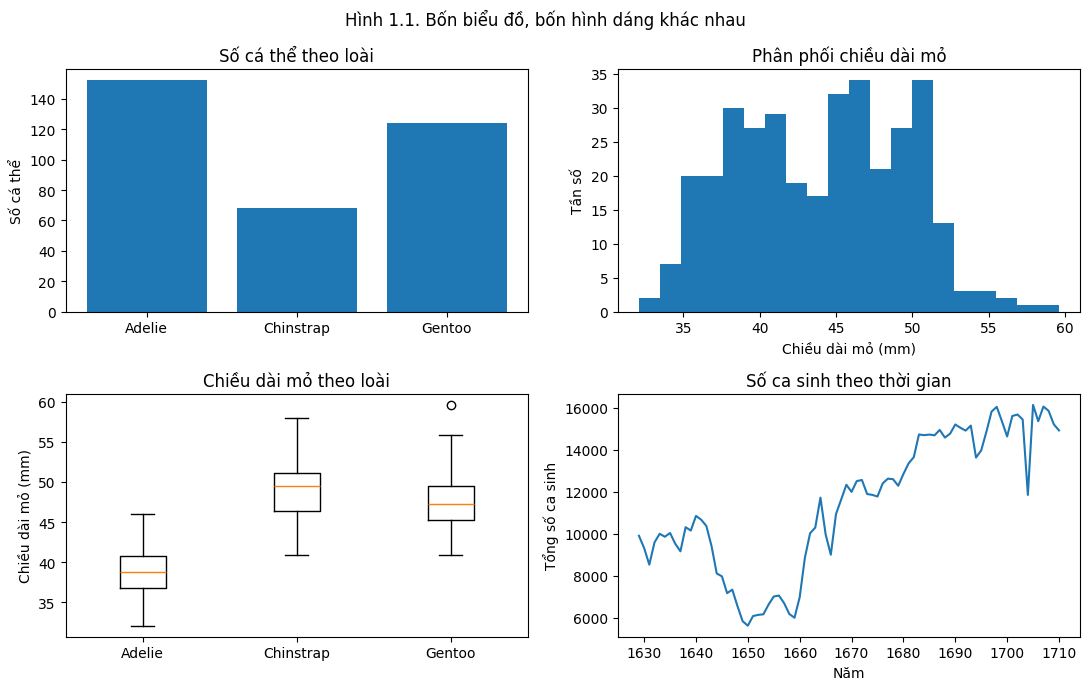

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

dem_loai = penguins["species"].value_counts().reindex(MAU_LOAI.keys())
axes[0, 0].bar(dem_loai.index, dem_loai.values)
axes[0, 0].set_title("Số cá thể theo loài")
axes[0, 0].set_ylabel("Số cá thể")

axes[0, 1].hist(penguins["bill_length_mm"].dropna(), bins=20)
axes[0, 1].set_title("Phân phối chiều dài mỏ")
axes[0, 1].set_xlabel("Chiều dài mỏ (mm)")
axes[0, 1].set_ylabel("Tần số")

mo_theo_loai = [penguins.loc[penguins["species"] == loai, "bill_length_mm"].dropna() for loai in MAU_LOAI]
axes[1, 0].boxplot(mo_theo_loai)
axes[1, 0].set_xticks([1, 2, 3], list(MAU_LOAI))
axes[1, 0].set_title("Chiều dài mỏ theo loài")
axes[1, 0].set_ylabel("Chiều dài mỏ (mm)")

axes[1, 1].plot(arbuthnot["year"], arbuthnot["total"])
axes[1, 1].set_title("Số ca sinh theo thời gian")
axes[1, 1].set_xlabel("Năm")
axes[1, 1].set_ylabel("Tổng số ca sinh")

plt.suptitle("Hình 1.1. Bốn biểu đồ, bốn hình dáng khác nhau")
plt.tight_layout()
plt.show()

> **W03-Q01 ⋆ — Điều gì lặp lại?** Nhìn bốn biểu đồ trên. Hãy nêu ba loại quyết định mà người vẽ phải đưa ra trước khi có một biểu đồ hoàn chỉnh. Chưa cần dùng đúng thuật ngữ; mô tả bằng lời là đủ.

<details><summary>Đáp án</summary>

Ba quyết định lặp lại ở cả bốn hình:

1. **Dùng dữ liệu nào**, và dữ liệu đó phải có những biến nào (loài, chiều dài mỏ, năm, số ca sinh...).
2. **Mã hóa mỗi biến bằng dấu hiệu trực quan nào**: vị trí trên trục x, trục y, màu, kích thước...
3. **Vẽ các quan sát bằng hình gì**: cột, hộp, đường, điểm...

Ba câu hỏi này chính là xương sống của Ngữ pháp đồ họa.
</details>

### 1.2 Một biểu đồ có thể "phân tích cú pháp"

Ngữ pháp tiếng Việt cho biết một câu gồm chủ ngữ, vị ngữ, bổ ngữ. Năm 1999, nhà thống kê Leland Wilkinson xuất bản cuốn *The Grammar of Graphics*, làm điều tương tự cho biểu đồ thống kê. Hầu hết phần mềm vẽ biểu đồ ngày nay (ggplot2 trong R, Tableau, Plotly, các thư viện Python như seaborn, altair, plotnine) đều chịu ảnh hưởng của cuốn sách này.

<img src="figures/stat20_ngu_phap_do_hoa.png" width="560">

*Hình 1.2. Ngữ pháp đồ họa xem một biểu đồ như các lớp chồng lên nhau: dữ liệu, thuộc tính hình ảnh (aesthetics), dạng hình học (geometries), facet, thống kê, hệ tọa độ, chủ đề. Nguồn hình: STAT 20, bản dịch tiếng Việt, §2.6.1.*

Trong khóa học này, dùng phiên bản gọn:

$$
\text{Biểu đồ} = \text{Dữ liệu} + \text{Ánh xạ thuộc tính hình ảnh} + \text{Dạng hình học} \; (+ \text{nhóm / facet khi cần}).
$$

Ba thành phần đầu tạo nên lõi của mọi biểu đồ. Thành phần thứ tư là cách có hệ thống để đưa thêm một biến phân nhóm vào. Không lựa chọn nào trong số này là "trang trí": chúng quyết định thông tin nào được giữ, thông tin nào bị che, và điều gì được nhấn mạnh.

Ta xem từng thành phần qua một biểu đồ duy nhất, gọi là "biểu đồ chim cánh cụt".

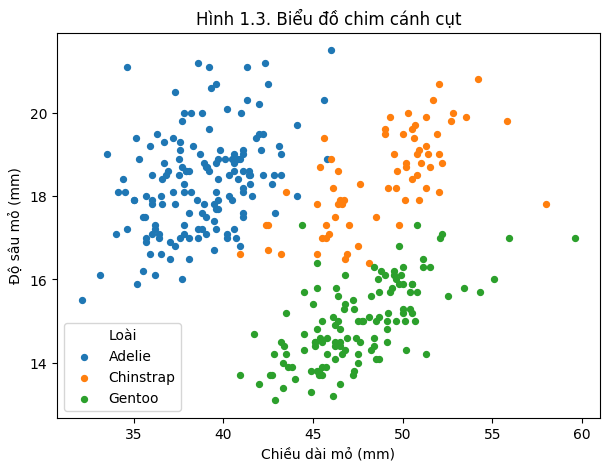

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
for loai, nhom in penguins.groupby("species"):
    ax.scatter(nhom["bill_length_mm"], nhom["bill_depth_mm"], s=18, color=MAU_LOAI[loai], label=loai)
ax.set_xlabel("Chiều dài mỏ (mm)")
ax.set_ylabel("Độ sâu mỏ (mm)")
ax.legend(title="Loài")
ax.set_title("Hình 1.3. Biểu đồ chim cánh cụt")
plt.show()

**Thành phần 1: Dữ liệu.** Trước khi nghĩ đến màu hay loại biểu đồ, hãy hỏi: dữ liệu có chứa những biến cần thiết để trả lời câu hỏi không? Để vẽ Hình 1.3 cần tối thiểu ba cột:

| Biến | Ý nghĩa |
|---|---|
| `bill_length_mm` | chiều dài mỏ, mm |
| `bill_depth_mm` | độ sâu mỏ, mm |
| `species` | loài |

Không biểu đồ nào "bổ sung" được một biến mà dữ liệu chưa từng ghi lại. Rất nhiều biểu đồ hỏng ngay từ bước này: dữ liệu không khớp với thông điệp muốn truyền tải.

**Thành phần 2: Ánh xạ thuộc tính hình ảnh.** *Ánh xạ* một biến nghĩa là để biến đó điều khiển một đặc trưng trực quan. Trong Hình 1.3:

- `bill_length_mm` điều khiển vị trí trên trục x (mỏ dài nằm bên phải);
- `bill_depth_mm` điều khiển vị trí trên trục y;
- `species` điều khiển màu.

<img src="figures/stat20_anh_xa_thuoc_tinh.png" width="560">

*Hình 1.4. Ánh xạ: mỗi cột của data frame được nối tới một thuộc tính của biểu đồ (x, y, màu). Nguồn hình: STAT 20, bản dịch tiếng Việt, §2.7.2.1.*

Các thuộc tính hay dùng: `x`, `y`, `color` (màu viền hoặc màu điểm), `fill` (màu tô bên trong), `alpha` (độ trong suốt), `size` (kích thước), `shape` (hình dạng điểm). Không phải thuộc tính nào cũng hợp với mọi loại biến: kích thước hợp với biến số, còn hình dạng điểm chỉ hợp với biến phân loại có ít mức.

**Thành phần 3: Dạng hình học.** Dạng hình học quyết định mỗi quan sát được vẽ bằng dấu hiệu gì. Khi gọi một hình là "biểu đồ phân tán", "biểu đồ cột" hay "histogram", thực ra ta đang gọi tên dạng hình học của nó.

| Dạng hình học | Nhấn mạnh |
|---|---|
| điểm | từng quan sát; quan hệ giữa hai biến số |
| đường | diễn biến theo một thứ tự có ý nghĩa (thời gian) |
| cột | số đếm hoặc tỉ lệ theo từng mức của biến phân loại |
| histogram, mật độ | hình dạng phân phối của một biến số |
| hộp, violin | trung tâm và độ phân tán theo nhóm |

Cùng dữ liệu, cùng ánh xạ, đổi dạng hình học là đổi thông điệp. Hình dưới giữ nguyên dữ liệu và ánh xạ (chiều dài mỏ theo trục y, loài theo trục x), chỉ đổi dạng hình học.

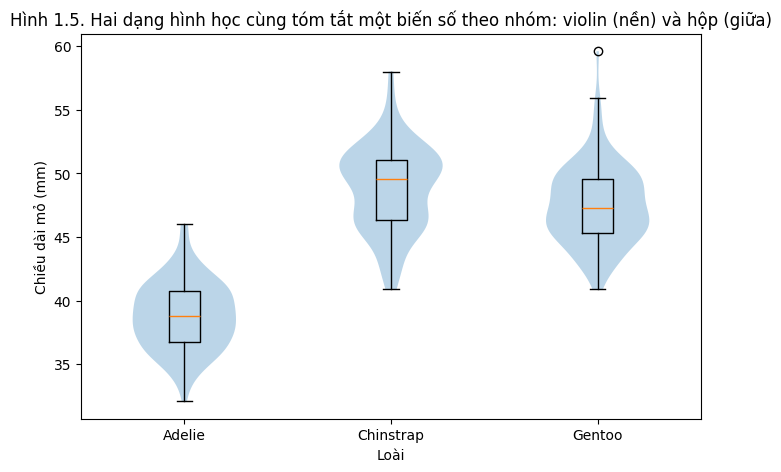

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.violinplot(mo_theo_loai, showextrema=False)
ax.boxplot(mo_theo_loai, widths=0.15)
ax.set_xticks([1, 2, 3], list(MAU_LOAI))
ax.set_xlabel("Loài")
ax.set_ylabel("Chiều dài mỏ (mm)")
ax.set_title("Hình 1.5. Hai dạng hình học cùng tóm tắt một biến số theo nhóm: violin (nền) và hộp (giữa)")
plt.show()

Violin cho thấy hình dạng phân phối trong mỗi loài; hộp cho thấy trung vị, tứ phân vị và điểm ngoại lai. Chọn dạng hình học theo câu hỏi và đơn vị quan sát, không theo thói quen.

**Thành phần 4: Nhóm và facet.** Khi có một biến thứ ba đáng quan tâm, ta có thể dùng nó để *nhóm* các quan sát bằng màu, hình dạng hoặc kiểu nét (như `species` trong Hình 1.3), hoặc để *chia* thành các facet, mỗi ô vẽ một nhóm.

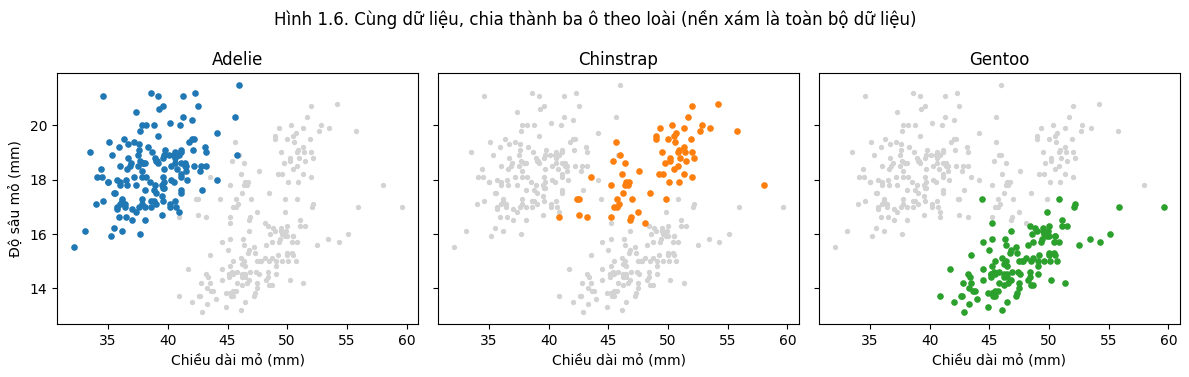

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True)
for ax, (loai, nhom) in zip(axes, penguins.groupby("species")):
    ax.scatter(penguins["bill_length_mm"], penguins["bill_depth_mm"], s=8, color="lightgray")
    ax.scatter(nhom["bill_length_mm"], nhom["bill_depth_mm"], s=14, color=MAU_LOAI[loai])
    ax.set_title(loai)
    ax.set_xlabel("Chiều dài mỏ (mm)")
axes[0].set_ylabel("Độ sâu mỏ (mm)")
plt.suptitle("Hình 1.6. Cùng dữ liệu, chia thành ba ô theo loài (nền xám là toàn bộ dữ liệu)")
plt.tight_layout()
plt.show()

Nhóm hay chia ô đều là một cách **điều kiện hóa bằng hình**: xem cấu trúc dữ liệu bên trong từng mức của một biến phân nhóm. Phần 4 sẽ làm điều tương tự bằng con số.

> **W03-EX01 ⋆⋆ — Phân tích cú pháp một biểu đồ.** Với Hình 1.3:
> 1. Dữ liệu cần chứa những biến nào?
> 2. Biến nào được ánh xạ tới x, y và màu?
> 3. Dạng hình học là gì?
> 4. Nếu bỏ `species`, thông tin nào biến mất?
> 5. *Tình huống giả định:* bản trích dữ liệu chỉ có ba biến trên. Có dùng nó để so sánh theo `island` được không?

Chạy ô dưới để xem câu 4 trông thế nào.

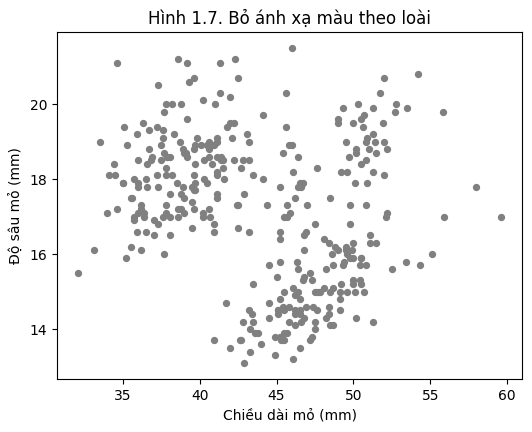

In [6]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(penguins["bill_length_mm"], penguins["bill_depth_mm"], s=18, color="gray")
ax.set_xlabel("Chiều dài mỏ (mm)")
ax.set_ylabel("Độ sâu mỏ (mm)")
ax.set_title("Hình 1.7. Bỏ ánh xạ màu theo loài")
plt.show()

<details><summary>Đáp án</summary>

1. `bill_length_mm`, `bill_depth_mm`, `species`.
2. `bill_length_mm` tới x; `bill_depth_mm` tới y; `species` tới màu.
3. Điểm.
4. Vẫn thấy các cặp (chiều dài, độ sâu), nhưng không còn biết cụm nào là loài nào. Ở Hình 1.7, đám mây điểm trông như chiều dài và độ sâu mỏ hầu như không liên quan, thậm chí hơi ngược chiều; khi tô màu theo loài, trong mỗi loài lại thấy mỏ dài hơn đi cùng mỏ sâu hơn. Một ánh xạ mới không chỉ "đổi màu", nó làm lộ cấu trúc nhóm mà biểu đồ hai biến che mất.
5. Không. `island` không có trong bản trích, nên biểu đồ không thể mã hóa biến đó cho tới khi bổ sung dữ liệu hợp lệ.
</details>

### 1.3 Ánh xạ hay thiết lập?

> **W03-EX02 ⋆⋆.** Hai đoạn code đều nhắc tới màu. Hai cách chỉ định màu đóng vai trò thống kê giống nhau hay khác nhau? Đoán trước, rồi chạy ô dưới.
>
> ```python
> # A
> ax.scatter(x=penguins["bill_length_mm"], y=penguins["bill_depth_mm"],
>            c=penguins["species"].astype("category").cat.codes)
> # B
> ax.scatter(x=penguins["bill_length_mm"], y=penguins["bill_depth_mm"],
>            color="tab:blue")
> ```

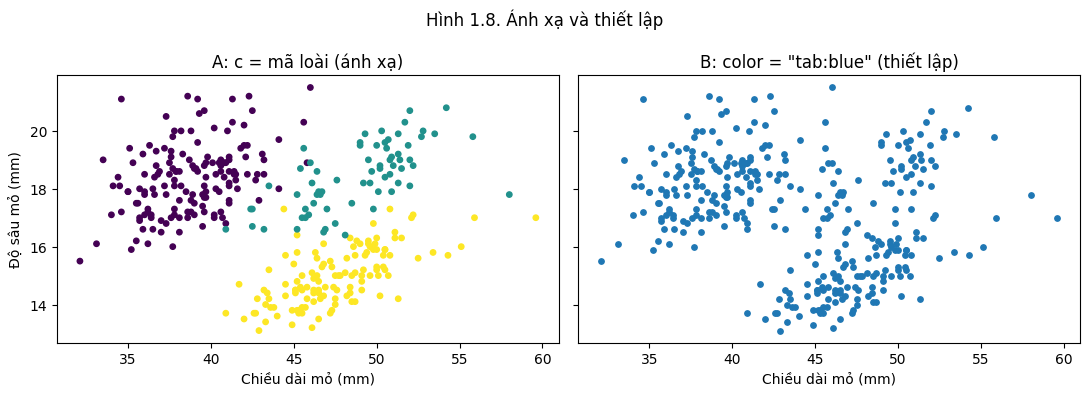

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].scatter(x=penguins["bill_length_mm"], y=penguins["bill_depth_mm"],
                c=penguins["species"].astype("category").cat.codes, s=15)
axes[0].set_title("A: c = mã loài (ánh xạ)")
axes[1].scatter(x=penguins["bill_length_mm"], y=penguins["bill_depth_mm"],
                color="tab:blue", s=15)
axes[1].set_title('B: color = "tab:blue" (thiết lập)')
for ax in axes:
    ax.set_xlabel("Chiều dài mỏ (mm)")
axes[0].set_ylabel("Độ sâu mỏ (mm)")
plt.suptitle("Hình 1.8. Ánh xạ và thiết lập")
plt.tight_layout()
plt.show()

<details><summary>Đáp án</summary>

Khác nhau. Ở A, `c=...` nhận một dãy giá trị suy ra từ `species`, nên màu thay đổi theo dữ liệu: đó là **ánh xạ**. Ở B, `color="tab:blue"` là một giá trị cố định, mọi điểm cùng một màu: đó là **thiết lập**.

Ánh xạ trả lời "biến nào điều khiển thuộc tính này?". Thiết lập chỉ quyết định cách hiển thị và không mang thông tin nào về dữ liệu.
</details>

STAT 20 kể một tình huống vui: trong ggplot2, nếu viết `color = "blue"` *bên trong* phần ánh xạ, R hiểu rằng bạn muốn ánh xạ màu theo một "biến" có giá trị hằng là chữ "blue", và tô tất cả điểm bằng... màu đỏ mặc định kèm một chú giải ghi "blue". Lỗi này nhắc rằng ánh xạ và thiết lập là hai việc khác nhau, dù cú pháp trông gần giống.

Thiết lập vẫn có ích, ví dụ giảm độ đậm (`alpha`) để thấy các điểm chồng nhau:

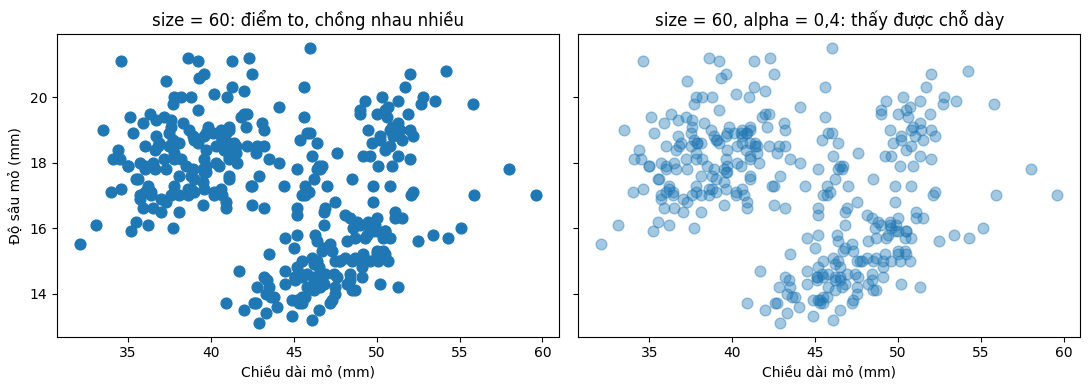

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].scatter(penguins["bill_length_mm"], penguins["bill_depth_mm"], color="tab:blue", s=60)
axes[0].set_title("size = 60: điểm to, chồng nhau nhiều")
axes[1].scatter(penguins["bill_length_mm"], penguins["bill_depth_mm"], color="tab:blue", s=60, alpha=0.4)
axes[1].set_title("size = 60, alpha = 0,4: thấy được chỗ dày")
for ax in axes:
    ax.set_xlabel("Chiều dài mỏ (mm)")
axes[0].set_ylabel("Độ sâu mỏ (mm)")
plt.tight_layout()
plt.show()

> **W03-CH01 ⋆⋆⋆ — Dạng hình học có phải chỉ là phong cách?** OpenIntro dùng biểu đồ hộp dưới đây để so sánh số câu lạc bộ mỗi sinh viên tham gia theo năm học. Một sinh viên đề nghị thay toàn bộ biểu đồ hộp bằng các điểm rồi nối các điểm bằng đường, "vì năm học có thứ tự". Hãy đánh giá đề nghị đó bằng Ngữ pháp đồ họa.
>
> *OpenIntro không công bố dữ liệu gốc của hình này; ô dưới mô phỏng dữ liệu có hình dạng tương tự. Hình bên phải vẽ đúng đề nghị của sinh viên kia.*

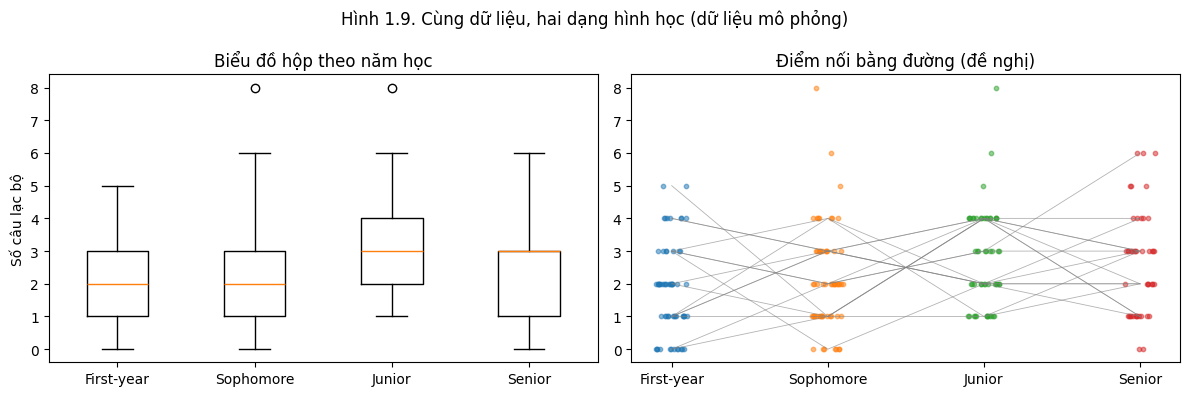

In [9]:
nam_hoc = ["First-year", "Sophomore", "Junior", "Senior"]
so_cau_lac_bo = {
    "First-year": np.clip(rng.poisson(2.0, 60), 0, 6),
    "Sophomore": np.append(np.clip(rng.poisson(2.2, 55), 0, 4), [5, 6, 8]),
    "Junior": np.append(np.clip(rng.poisson(2.6, 50), 1, 4), [5, 6, 8]),
    "Senior": np.clip(rng.poisson(2.4, 45), 0, 6),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([so_cau_lac_bo[n] for n in nam_hoc])
axes[0].set_xticks([1, 2, 3, 4], nam_hoc)
axes[0].set_ylabel("Số câu lạc bộ")
axes[0].set_title("Biểu đồ hộp theo năm học")

for i, n in enumerate(nam_hoc):
    axes[1].scatter(np.full(len(so_cau_lac_bo[n]), i + 1) + rng.uniform(-0.1, 0.1, len(so_cau_lac_bo[n])),
                    so_cau_lac_bo[n], s=10, alpha=0.5)
duong_noi = [so_cau_lac_bo[n][:15] for n in nam_hoc]
for j in range(15):
    axes[1].plot([1, 2, 3, 4], [d[j] for d in duong_noi], color="gray", linewidth=0.6, alpha=0.6)
axes[1].set_xticks([1, 2, 3, 4], nam_hoc)
axes[1].set_title("Điểm nối bằng đường (đề nghị)")
plt.suptitle("Hình 1.9. Cùng dữ liệu, hai dạng hình học (dữ liệu mô phỏng)")
plt.tight_layout()
plt.show()

<details><summary>Đáp án</summary>

Đề nghị đó không tương đương với biểu đồ gốc.

Dữ liệu có một biến nhóm (năm học) và một biến số (số câu lạc bộ), và mỗi sinh viên chỉ thuộc **một** năm học. Biểu đồ hộp tóm tắt phân phối trong từng nhóm: trung vị, khoảng tứ phân vị, giá trị ngoại lai.

Nối các điểm bằng đường (hình phải) ngầm nói rằng một sinh viên năm nhất "đi tiếp" thành một sinh viên năm hai cụ thể, tức là tạo ra những quỹ đạo mà dữ liệu không hề có. Việc năm học có thứ tự không đủ để biện minh cho đường nối giữa các đơn vị quan sát khác nhau. Đường nối chỉ hợp lý khi cùng một đơn vị được theo dõi qua thời gian, như số ca sinh của London theo từng năm ở phần sau.

Dạng hình học phải phù hợp với đơn vị quan sát và câu hỏi, không chỉ với kiểu dữ liệu của trục x.
</details>

---
## Phần 2. Số ca sinh theo thời gian: cùng dữ liệu, thay đổi cách biểu diễn

### 2.1 Bối cảnh

Ở London thế kỷ 17, John Arbuthnot thu thập số trẻ được rửa tội mỗi năm, tách theo bé trai và bé gái. Data frame `arbuthnot` có 82 hàng, mỗi hàng là một năm từ 1629 đến 1710; ta dùng biến `year` (năm) và `total` (tổng số ca, bằng `boys + girls`).

In [10]:
arbuthnot[["year", "total"]].head(6)

,year,total
0,1629,9901
1,1630,9315
2,1631,8524
3,1632,9584
4,1633,9997
5,1634,9855


Mỗi hàng là một năm, và các năm có thứ tự thời gian thật sự. Đây là loại dữ liệu mà đường nối có ý nghĩa.

### 2.2 Biểu đồ đường trả lời điều gì?

Phân tích cú pháp: dữ liệu là 82 năm; `year` tới x, `total` tới y; dạng hình học là đường.

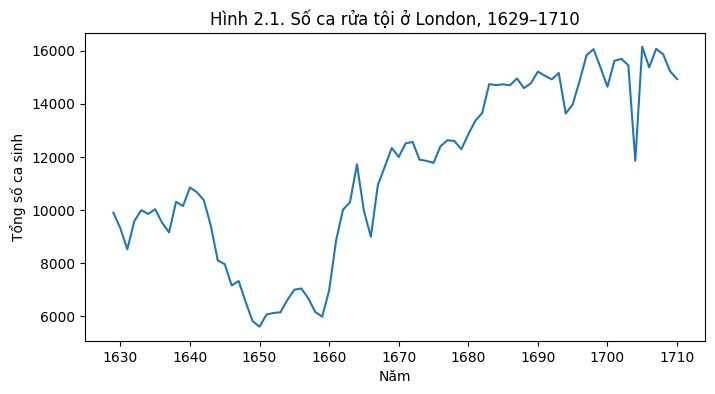

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(arbuthnot["year"], arbuthnot["total"])
ax.set_xlabel("Năm")
ax.set_ylabel("Tổng số ca sinh")
ax.set_title("Hình 2.1. Số ca rửa tội ở London, 1629–1710")
plt.show()

Đường làm nổi bật diễn biến chung: giảm mạnh từ đầu những năm 1640 tới khoảng 1660, rồi tăng đều tới cuối thế kỷ.

> **W03-Q02 ⋆ — Đổi dạng hình học, đổi thông điệp?** Giữ nguyên dữ liệu và hai ánh xạ `year` tới x, `total` tới y. Nếu thay đường bằng điểm, điều gì trở nên dễ nhìn hơn và điều gì kém nổi bật hơn?

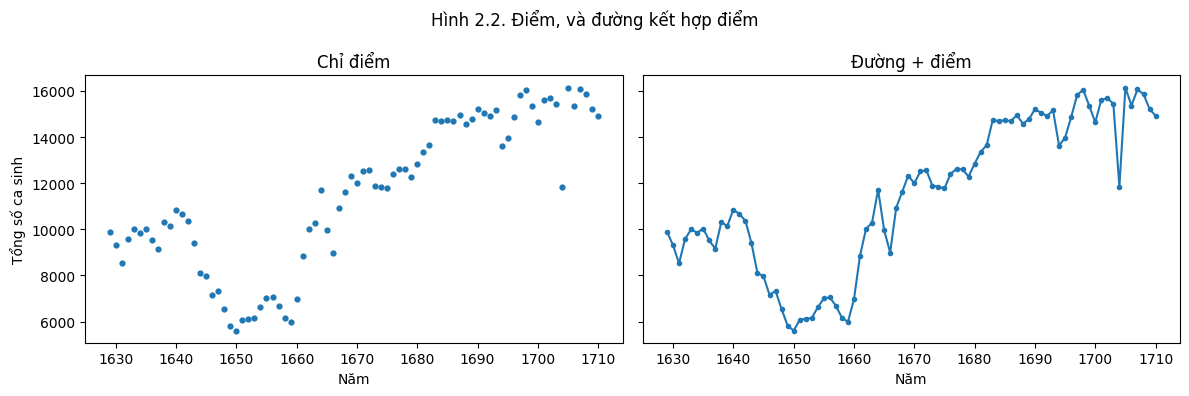

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].scatter(arbuthnot["year"], arbuthnot["total"], s=12)
axes[0].set_title("Chỉ điểm")
axes[1].plot(arbuthnot["year"], arbuthnot["total"], marker="o", markersize=3)
axes[1].set_title("Đường + điểm")
for ax in axes:
    ax.set_xlabel("Năm")
axes[0].set_ylabel("Tổng số ca sinh")
plt.suptitle("Hình 2.2. Điểm, và đường kết hợp điểm")
plt.tight_layout()
plt.show()

<details><summary>Đáp án W03-Q02</summary>

Điểm làm rõ giá trị của từng năm, ví dụ dễ thấy năm 1704 bất thường thấp. Đường làm rõ hơn tính liên tục theo thời gian và xu hướng chung. Không có dạng hình học "tốt nhất" trong chân không; câu hỏi đúng là: dạng nào phục vụ thông điệp đang cần truyền đạt?
</details>

Kết hợp nhiều lớp (hình phải) cho thấy cả xu hướng lẫn từng năm, nhưng cũng làm hình rối hơn, nên mỗi thông điệp riêng lẻ lại kém rõ. Một ví dụ kết hợp lớp khác mà STAT 20 đưa ra để bạn tự đánh giá: đặt đường mật độ chồng lên histogram.

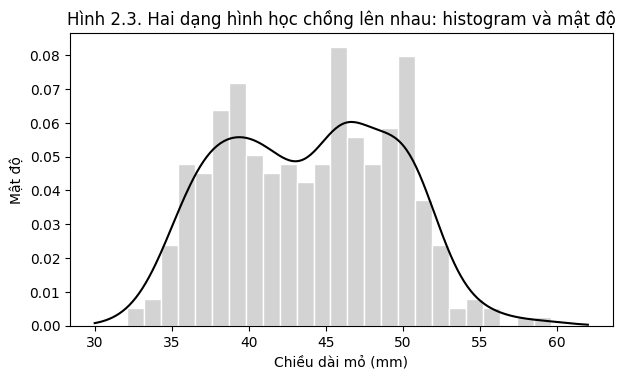

In [13]:
from scipy import stats
mo = penguins["bill_length_mm"].dropna()
luoi = np.linspace(30, 62, 300)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(mo, bins=25, density=True, color="lightgray", edgecolor="white")
ax.plot(luoi, stats.gaussian_kde(mo)(luoi), color="black")
ax.set_xlabel("Chiều dài mỏ (mm)")
ax.set_ylabel("Mật độ")
ax.set_title("Hình 2.3. Hai dạng hình học chồng lên nhau: histogram và mật độ")
plt.show()

Có nên làm vậy không? Histogram dạng bậc thang cho thấy số liệu thật trong từng khoảng; đường cong mượt cho thấy hình dạng tổng thể nhanh hơn nhưng phụ thuộc vào băng thông. Đặt chung có thể giúp người đọc đối chiếu, cũng có thể chỉ làm hình nặng thêm.

> **W03-EX03 ⋆⋆ — "Càng nhiều lớp càng tốt"?** Phản biện khẳng định: "Biểu đồ đường + điểm luôn tốt hơn biểu đồ chỉ có đường vì nó chứa nhiều thông tin hơn." Nêu ít nhất hai lý do.

<details><summary>Đáp án</summary>

Khẳng định sai.

1. Thêm điểm giúp đọc từng quan sát nhưng có thể làm đường xu hướng khó nhìn hơn.
2. Một biểu đồ tốt được tối ưu cho một câu hỏi hay thông điệp, không phải để tối đa số dấu hiệu trực quan.
3. Khi dữ liệu dày, nhiều lớp gây chồng lấp và tăng tải nhận thức.

Thêm một lớp khi lớp đó cung cấp thông tin mà câu hỏi cần, không chỉ vì phần mềm cho phép.
</details>

### 2.3 Giao tiếp bằng đồ họa: nhãn và chú thích

Khi vẽ để tự khám phá dữ liệu, bạn là người xem duy nhất, và nhãn `bill_length_mm` là đủ. Khi vẽ cho người khác, cần nghĩ xem họ biết gì. Hai công cụ đơn giản nhất là **nhãn** (tên trục có đơn vị, tiêu đề nói lên thông điệp chính) và **chú thích** (annotation) chỉ vào chỗ quan trọng.

Sự sụt giảm số ca rửa tội sau năm 1642 trùng với thời điểm Nội chiến Anh bắt đầu. Ô dưới thêm chú thích đó vào Hình 2.1.

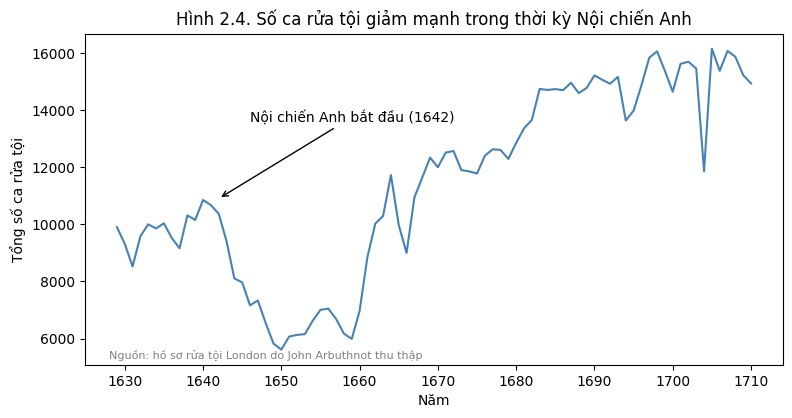

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(arbuthnot["year"], arbuthnot["total"], color="steelblue")
ax.annotate("Nội chiến Anh bắt đầu (1642)", xy=(1642, 10900), xytext=(1646, 13600),
            arrowprops=dict(arrowstyle="->"), fontsize=10)
ax.set_xlabel("Năm")
ax.set_ylabel("Tổng số ca rửa tội")
ax.set_title("Hình 2.4. Số ca rửa tội giảm mạnh trong thời kỳ Nội chiến Anh")
ax.text(1628, 5300, "Nguồn: hồ sơ rửa tội London do John Arbuthnot thu thập", fontsize=8, color="gray")
plt.show()

Tiêu đề Hình 2.4 không mô tả "đây là biểu đồ gì", mà nói điều người đọc nên thấy. Còn những chỗ sụt khác, như quanh năm 1666 hay năm 1704, thì sao? Bạn có thể tự tìm hiểu lịch sử London thời kỳ đó và thêm chú thích.

---
## Phần 3. Python và Ngữ pháp đồ họa

### 3.1 Code phản chiếu cấu trúc khái niệm

Matplotlib không có cú pháp "cộng lớp" như ggplot2, nhưng vẫn đọc được theo ba câu hỏi của ngữ pháp:

```python
fig, ax = plt.subplots()
ax.scatter(
    x=penguins["bill_length_mm"],
    y=penguins["bill_depth_mm"],
    c=penguins["species"].astype("category").cat.codes,
)
```

1. **Dữ liệu nào?** `penguins`.
2. **Biến nào ánh xạ vào đâu?** Các đối số `x=`, `y=`, `c=` nhận giá trị từ các cột.
3. **Quan sát được vẽ bằng gì?** `ax.scatter(...)` tạo các điểm.

Có thể viết từng bước để các quyết định tách bạch:

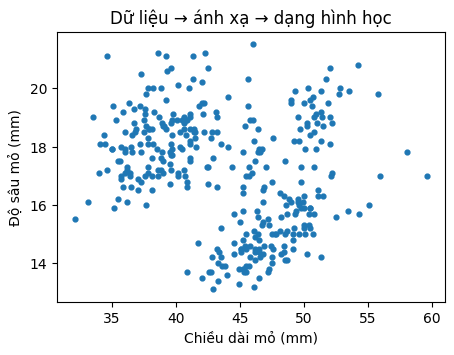

In [15]:
# Bước 1: chọn dữ liệu cần dùng
du_lieu = penguins[["bill_length_mm", "bill_depth_mm"]]

# Bước 2: ánh xạ biến vào trục
x = du_lieu["bill_length_mm"]
y = du_lieu["bill_depth_mm"]

# Bước 3: dạng hình học
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.scatter(x, y, s=12)
ax.set(xlabel="Chiều dài mỏ (mm)", ylabel="Độ sâu mỏ (mm)", title="Dữ liệu → ánh xạ → dạng hình học")
plt.show()

> **W03-PY01 ⋆ — Đọc code, không chạy code.** Với đoạn code ở mục 3.1:
> 1. Ba biến nào xuất hiện trong biểu đồ?
> 2. Biến nào điều khiển màu?
> 3. Mỗi điểm đại diện cho gì?
> 4. Các hàng thiếu `bill_length_mm` hoặc `bill_depth_mm` có được vẽ không?

<details><summary>Đáp án</summary>

1. `bill_length_mm`, `bill_depth_mm`, `species`.
2. `species`.
3. Một con chim cánh cụt có đủ hai số đo mỏ.
4. Không. Trong 344 hàng, chỉ 342 hàng có đủ hai số đo này nên chỉ có 342 điểm. Đọc code có giá trị vì kiểm tra được logic thống kê trước cả khi chạy chương trình.
</details>

In [16]:
print("Số hàng:", len(penguins))
print("Số hàng có đủ hai số đo mỏ:", penguins[["bill_length_mm", "bill_depth_mm"]].dropna().shape[0])

Số hàng: 344
Số hàng có đủ hai số đo mỏ: 342


> **W03-PY02 ⋆⋆ — Chỉ đổi một thành phần.** Hai đoạn code có cùng dữ liệu và ánh xạ:
>
> ```python
> fig_A, ax_A = plt.subplots()
> ax_A.plot(arbuthnot["year"], arbuthnot["total"])
>
> fig_B, ax_B = plt.subplots()
> ax_B.scatter(arbuthnot["year"], arbuthnot["total"])
> ```
>
> 1. Thành phần nào của ngữ pháp thay đổi?
> 2. Vì sao không nên nói "B chứa dữ liệu khác A"?
> 3. Nếu muốn nhấn mạnh diễn biến liên tục theo năm, chọn A hay B?

<details><summary>Đáp án</summary>

1. Chỉ dạng hình học: `plot` tạo đường, `scatter` tạo điểm.
2. Dữ liệu và ánh xạ `year` tới x, `total` tới y giữ nguyên. Hai hình chỉ mã hóa cùng các quan sát theo hai cách (xem Hình 2.1 và 2.2).
3. A, vì đường nối tận dụng thứ tự thời gian có ý nghĩa.

Lợi ích của một ngữ pháp là chỉ ra chính xác quyết định nào đã đổi.
</details>

> **W03-Q04 ⋆ — Biến hay nhãn?** Code dùng các biến `bill_length_mm`, `bill_depth_mm`, `species`. Khi làm biểu đồ tiếng Việt, có nên đổi tên ba biến trong dữ liệu chỉ để nhãn trục và chú giải hiển thị tiếng Việt không?

<details><summary>Đáp án</summary>

Không cần. Tên biến là một phần cấu trúc của bộ dữ liệu; nhãn hiển thị là phần giao tiếp với người đọc. Giữ nguyên tên biến và Việt hóa nhãn:

```python
ax.set(xlabel="Chiều dài mỏ (mm)", ylabel="Độ sâu mỏ (mm)")
ax.legend(title="Loài")
```

Mọi hình trong notebook này đều làm như vậy.
</details>

---
## Phần 4. Điều kiện hóa: lọc và tập trung vào nhóm quan tâm

### 4.1 Điều kiện hóa ở tuần này nghĩa là gì?

**Điều kiện hóa** dữ liệu là nghiên cứu một biến $Y$, hoặc mối liên hệ giữa $X$ và $Y$, **bên trong một mức** $Z = z$ của một biến khác. Trong thực tế đó có thể là lọc ra một tập con, chia dữ liệu thành nhóm, so sánh cùng một thống kê giữa các nhóm, hoặc tách biểu đồ theo nhóm.

Đừng nhầm với Tuần 05: ở phần xác suất, "có điều kiện" sẽ được định nghĩa chặt bằng xác suất có điều kiện. Tuần này chỉ dùng theo nghĩa phân tích dữ liệu theo tập con và nhóm. Thật ra bạn đã gặp nó ở Tuần 02: tỉ lệ theo hàng trong bảng liên hợp là tỉ lệ có điều kiện.

Nhắc lại hai loại tỉ lệ. Giả sử quan tâm tới kết quả `success` và một biến phân nhóm `difficulty`:

- **tỉ lệ biên**: gộp mọi mức `difficulty` rồi tính một tỉ lệ chung;
- **tỉ lệ có điều kiện**: tính riêng trong từng mức `difficulty` $= z$.

Hai loại tỉ lệ trả lời hai câu hỏi khác nhau, và một kết luận đúng ở mức biên không buộc phải đúng trong mọi nhóm. Phần 5 sẽ cho thấy điều này có thể đi xa đến mức nào.

### 4.2 Dữ liệu giấc ngủ của động vật có vú

Năm 2007, Savage và West công bố một mô hình lý thuyết về giấc ngủ của động vật có vú, liên hệ nó với tốc độ trao đổi chất và kích thước cơ thể. Data frame `msleep` gồm 83 loài; mỗi hàng là **một loài**. Ta dùng năm biến như STAT 20: `name` (tên), `sleep_total` (số giờ ngủ trung bình mỗi ngày), `log_bodywt` (logarit tự nhiên của khối lượng cơ thể tính bằng gam), `vore` (chế độ ăn), `conservation` (tình trạng bảo tồn).

Biến `log_bodywt` được tạo từ khối lượng gốc `bodywt` (kg):

In [17]:
msleep = msleep.assign(log_bodywt=np.log(msleep["bodywt"] * 1000))
msleep = msleep[["name", "sleep_total", "log_bodywt", "vore", "conservation"]]
msleep.head(10)

,name,sleep_total,log_bodywt,vore,conservation
0,Cheetah,12.1,10.819778,carni,lc
1,Owl monkey,17.0,6.173786,omni,NaN
2,Mountain beaver,14.4,7.207860,herbi,nt
3,Greater short-tailed shrew,14.9,2.944439,omni,lc
4,Cow,4.0,13.304685,herbi,domesticated
5,Three-toed sloth,14.4,8.255828,herbi,NaN
6,Northern fur seal,8.7,9.927692,carni,vu
7,Vesper mouse,7.0,3.806662,NaN,NaN
8,Dog,10.1,9.546813,carni,domesticated
9,Roe deer,3.0,9.602382,herbi,lc


Vì sao lấy logarit? Khối lượng các loài trải từ vài gam (chuột, dơi) tới vài tấn (voi). Trên thang thường, gần như mọi điểm dồn về một góc. Trên thang logarit, mỗi bước bằng nhau tương ứng với khối lượng *gấp* một số lần như nhau.

In [18]:
ten_can_ghi = ["Little brown bat", "African elephant"]

# Rê chuột lên một điểm để xem tên loài, chế độ ăn và tình trạng bảo tồn
fig = px.scatter(msleep, x="log_bodywt", y="sleep_total", hover_name="name",
                 hover_data={"vore": True, "conservation": True, "log_bodywt": ":.2f"},
                 labels={"log_bodywt": "log khối lượng cơ thể (gam)", "sleep_total": "Tổng thời gian ngủ (giờ/ngày)"},
                 title="Hình 4.1. Giấc ngủ và kích thước cơ thể của 83 loài", width=780, height=480)
fig.update_traces(marker=dict(size=9, opacity=0.7))
for ten in ten_can_ghi:
    dong = msleep[msleep["name"] == ten].iloc[0]
    fig.add_annotation(x=dong["log_bodywt"], y=dong["sleep_total"], text=ten, showarrow=True, arrowhead=0, ax=40, ay=-25)
fig.show()

Từ con dơi nâu nhỏ ngủ gần 20 giờ mỗi ngày tới con voi châu Phi ngủ chưa tới 4 giờ: loài càng nặng thường ngủ càng ít. Để hiểu kỹ hơn, ta đi vào các tập con.

### 4.3 Lọc giữ hàng, không chọn cột

Có hai cách cơ bản để cắt một data frame. Theo cột: **chọn** (select) một số biến. Theo hàng: **lọc** (filter) các quan sát thỏa một điều kiện trên giá trị của biến. Lọc mạnh hơn nhiều vì nó dựa trên nội dung dữ liệu.

Một phép lọc cần một **điều kiện**: một mệnh đề đúng hoặc sai cho từng hàng.

| Toán tử | Đọc là |
|---|---|
| `==` | bằng |
| `!=` | không bằng |
| `<`, `>` | nhỏ hơn, lớn hơn |
| `<=`, `>=` | nhỏ hơn hoặc bằng, lớn hơn hoặc bằng |

Vì sao `==` mà không phải `=`? Dấu `=` đã dùng để gán giá trị; `==` là câu hỏi "hai bên có bằng nhau không?".

In [19]:
msleep.query("name == 'Little brown bat'")

,name,sleep_total,log_bodywt,vore,conservation
42,Little brown bat,19.9,2.302585,insecti,NaN


> **W03-PY03 ⋆ — Đọc một phép lọc.** Với `large = msleep.query("log_bodywt > 12")`:
> 1. Kết quả có bao nhiêu hàng?
> 2. Số cột có thay đổi không?
> 3. Lệnh này chọn "biến lớn" hay chọn "động vật lớn"?
> 4. `log_bodywt > 12` là điều kiện trên biến nào?

In [20]:
large = msleep.query("log_bodywt > 12")
print("shape trước khi lọc:", msleep.shape, "  sau khi lọc:", large.shape)
large

shape trước khi lọc: (83, 5)   sau khi lọc: (9, 5)


,name,sleep_total,log_bodywt,vore,conservation
4,Cow,4.0,13.304685,herbi,domesticated
20,Asian elephant,3.9,14.750427,herbi,en
22,Horse,2.9,13.163505,herbi,domesticated
23,Donkey,3.1,12.138864,herbi,domesticated
29,Giraffe,1.9,13.710144,herbi,cd
30,Pilot whale,2.7,13.592367,carni,cd
35,African elephant,3.3,15.710729,herbi,vu
76,Brazilian tapir,4.4,12.242891,herbi,vu
79,Bottle-nosed dolphin,5.2,12.062953,carni,NaN


<details><summary>Đáp án</summary>

1. 9 hàng.
2. Không, vẫn giữ 5 cột.
3. Chọn các quan sát, tức là các loài thỏa điều kiện, không chọn biến.
4. `log_bodywt`.

Chín loài đó là bò, voi châu Á, ngựa, lừa, hươu cao cổ, cá voi hoa tiêu, voi châu Phi, heo vòi Brazil và cá heo mũi chai. Để ý $e^{12} \approx 163$ nghìn gam, tức khoảng 163 kg.
</details>

Lọc là thao tác hợp lệ khi tiêu chí xuất phát từ câu hỏi nghiên cứu. Vấn đề không nằm ở việc lọc, mà ở việc **đổi tiêu chí sau khi xem kết quả** chỉ để đạt kết luận mong muốn. Trước khi báo cáo một phân tích trên tập con, tự hỏi: tiêu chí lọc có đến từ mục tiêu phân tích không? Có nói rõ đang phân tích tập con nào không? Kết luận có bị diễn đạt như thể áp dụng cho toàn bộ dữ liệu không?

### 4.4 Nhiều điều kiện: "và" hay "hoặc"

- "và" (`and`, `&`) giữ các hàng thỏa **cả hai** điều kiện: phần giao, tập con thường nhỏ hơn.
- "hoặc" (`or`, `|`) giữ các hàng thỏa **ít nhất một** điều kiện: phần hợp, tập con thường lớn hơn.

> **W03-EX04 ⋆⋆ — Giao hay hợp?**
> A. Giữ động vật có `log_bodywt > 12` **và** `sleep_total < 5`.
> B. Giữ động vật có `log_bodywt > 12` **hoặc** `sleep_total < 5`.
>
> Không cần liệt kê hàng. Hãy dự đoán: (1) tập A hay B lớn hơn? (2) Vì sao A là điều kiện "chặt hơn"? (3) Một động vật nhỏ nhưng ngủ dưới 5 giờ thuộc A, B, hay không thuộc cả hai?

Hình dưới tô màu hai vùng tương ứng, rồi ô code tiếp theo đếm số hàng.

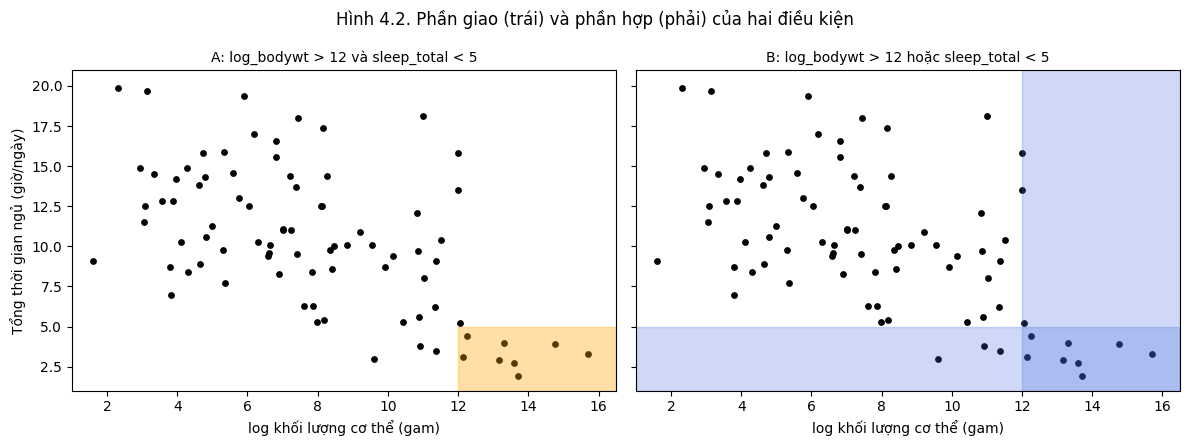

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, tieu_de in zip(axes, ["A: log_bodywt > 12 và sleep_total < 5", "B: log_bodywt > 12 hoặc sleep_total < 5"]):
    ax.scatter(msleep["log_bodywt"], msleep["sleep_total"], s=15, color="black")
    ax.set_xlabel("log khối lượng cơ thể (gam)")
    ax.set_title(tieu_de, fontsize=10)
axes[0].axvspan(12, 16.5, ymin=0, ymax=(5 - 1) / (21 - 1), color="orange", alpha=0.35)
axes[1].axvspan(12, 16.5, color="royalblue", alpha=0.25)
axes[1].axhspan(1, 5, color="royalblue", alpha=0.25)
for ax in axes:
    ax.set_xlim(1, 16.5)
    ax.set_ylim(1, 21)
axes[0].set_ylabel("Tổng thời gian ngủ (giờ/ngày)")
plt.suptitle("Hình 4.2. Phần giao (trái) và phần hợp (phải) của hai điều kiện")
plt.tight_layout()
plt.show()

In [22]:
tap_A = msleep.query("log_bodywt > 12 and sleep_total < 5")
tap_B = msleep.query("log_bodywt > 12 or sleep_total < 5")
print("A:", len(tap_A), "hàng   B:", len(tap_B), "hàng")
print("Lớn nhưng không thuộc A:", sorted(set(large["name"]) - set(tap_A["name"])))
print("Thuộc B nhưng không lớn:", sorted(set(tap_B["name"]) - set(large["name"])))

A: 8 hàng   B: 12 hàng
Lớn nhưng không thuộc A: ['Bottle-nosed dolphin']
Thuộc B nhưng không lớn: ['Caspian seal', 'Roe deer', 'Sheep']


<details><summary>Đáp án</summary>

1. B không thể nhỏ hơn A, vì B là hợp còn A là giao. Ở đây A có 8 hàng, B có 12.
2. A đòi hỏi hai mệnh đề cùng đúng.
3. Thuộc B, không thuộc A.

Trong 9 loài có `log_bodywt > 12`, điều kiện A loại cá heo mũi chai vì nó ngủ 5,2 giờ. Tập B thêm những loài không quá nặng nhưng ngủ ít, như hoẵng, cừu, hải cẩu Caspi.
</details>

Với biến phân loại danh nghĩa, phép so sánh thường dùng là `==`. Muốn lấy một trong nhiều giá trị, dùng `isin`:

In [23]:
msleep[msleep["name"].isin(["Little brown bat", "African elephant"])]

,name,sleep_total,log_bodywt,vore,conservation
35,African elephant,3.3,15.710729,herbi,vu
42,Little brown bat,19.9,2.302585,insecti,NaN


### 4.5 Điều kiện là một biến logic

Một phép so sánh trả về một cột `True`/`False`. Python coi `True` là 1 và `False` là 0, nên **tổng** của cột logic là số hàng thỏa điều kiện, còn **trung bình** là **tỉ lệ** hàng thỏa điều kiện.

In [24]:
a = pd.Series([2, 4, 6, 8])
print((a < 5).tolist())
print("Số phần tử < 5:", (a < 5).sum())
print("Tỉ lệ phần tử < 5:", (a < 5).mean())

[True, True, False, False]
Số phần tử < 5: 2
Tỉ lệ phần tử < 5: 0.5


Mẹo này sẽ dùng ngay ở phần sau để tính tỉ lệ theo nhóm.

---
## Phần 5. Pipeline và phép toán theo nhóm

### 5.1 Pipeline là một lập luận

Một phân tích thật thường có nhiều bước: dữ liệu ban đầu, lọc, sắp xếp, nhóm, tóm tắt, diễn giải. Điều quan trọng không phải viết ít dòng code, mà là trả lời được: **mỗi bước làm dữ liệu thay đổi thế nào, và vì sao câu hỏi cần bước đó?**

pandas cho phép nối các bước bằng dấu chấm, gọi là method chaining (method chaining):

In [25]:
(
    msleep
    .query("log_bodywt > 12")
    .sort_values("log_bodywt", ascending=False)
)

,name,sleep_total,log_bodywt,vore,conservation
35,African elephant,3.3,15.710729,herbi,vu
20,Asian elephant,3.9,14.750427,herbi,en
29,Giraffe,1.9,13.710144,herbi,cd
30,Pilot whale,2.7,13.592367,carni,cd
4,Cow,4.0,13.304685,herbi,domesticated
22,Horse,2.9,13.163505,herbi,domesticated
76,Brazilian tapir,4.4,12.242891,herbi,vu
23,Donkey,3.1,12.138864,herbi,domesticated
79,Bottle-nosed dolphin,5.2,12.062953,carni,NaN


Đọc gần như một câu: lấy `msleep`, giữ các loài có `log_bodywt > 12`, rồi sắp xếp giảm dần theo `log_bodywt`. Khi chuỗi quá dài, tách thành các bước có tên trung gian sẽ dễ đọc hơn.

> **W03-PY04 ⋆ — Dịch code thành tiếng Việt.** Với chuỗi ở trên: (1) bước nào làm giảm số hàng? (2) bước nào chỉ đổi thứ tự hàng? (3) nếu đảo hai bước, tập quan sát cuối có đổi không, thứ tự cuối có đổi không?

<details><summary>Đáp án</summary>

1. `.query(...)`.
2. `.sort_values(...)`.
3. Với hai thao tác này, đảo thứ tự vẫn ra cùng 9 loài, và vì cuối cùng vẫn sắp giảm dần nên thứ tự cũng như nhau. Nhưng không phải cặp thao tác nào cũng đổi chỗ được. Khi có tóm tắt theo nhóm, thứ tự có thể đổi cả câu hỏi, như bài tiếp theo.
</details>

> **W03-EX05 ⋆⋆⋆ — Thứ tự thay đổi câu hỏi.** Hai chuỗi A và B trả lời hai câu hỏi nào? Đoán trước khi chạy.

In [26]:
chuoi_A = (
    msleep
    .query("sleep_total > 8")
    .groupby("vore", dropna=False)
    .size()
    .reset_index(name="n_gt_8")
    .query("n_gt_8 > 18")
)
chuoi_B = (
    msleep
    .groupby("vore", dropna=False)
    .size()
    .reset_index(name="n")
    .query("n > 18")
)
print("A:\n", chuoi_A, "\n")
print("B:\n", chuoi_B)

A:
     vore  n_gt_8
1  herbi      19
3   omni      19 

B:
     vore   n
0  carni  19
1  herbi  32
3   omni  20


<details><summary>Đáp án</summary>

A: Chế độ ăn nào có **hơn 18 loài ngủ trên 8 giờ**? Kết quả: `herbi` (19), `omni` (19).

B: Chế độ ăn nào có **hơn 18 loài trong toàn bộ dữ liệu**? Kết quả: `carni` (19), `herbi` (32), `omni` (20).

Lọc trước khi đếm theo nhóm và lọc sau khi đếm theo nhóm không phải cùng một thao tác.
</details>

### 5.2 Lọc hay nhóm?

> **W03-Q03 ⋆.** Chọn thao tác phù hợp cho từng câu hỏi: (1) "Thời gian ngủ trung bình của động vật ăn thịt là bao nhiêu?" (2) "Thời gian ngủ trung bình của từng chế độ ăn là bao nhiêu?"

<details><summary>Đáp án</summary>

1. Một nhóm cụ thể: **lọc** `vore == "carni"`, rồi tóm tắt.
2. Cùng một phép tóm tắt cho mọi mức của `vore`: **nhóm** theo `vore`, rồi tóm tắt.

Lọc thu dữ liệu về một tập con. Nhóm giữ nguyên các quan sát nhưng thay đổi cách phép toán tiếp theo được áp dụng.
</details>

In [27]:
print("(1) Lọc rồi tóm tắt:")
print(msleep.query("vore == 'carni'")["sleep_total"].agg(["mean", "size"]).round(2), "\n")
print("(2) Nhóm rồi tóm tắt:")
print(msleep.groupby("vore", dropna=False)["sleep_total"].agg(["mean", "size"]).round(2))

(1) Lọc rồi tóm tắt:
mean    10.38
size    19.00
Name: sleep_total, dtype: float64 

(2) Nhóm rồi tóm tắt:
          mean  size
vore                
carni    10.38    19
herbi     9.51    32
insecti  14.94     5
omni     10.92    20
NaN      10.19     7


### 5.3 Nhóm rồi tóm tắt

Hình dưới cho thấy điều gì xảy ra: data frame được gắn nhãn nhóm cho từng hàng, rồi mỗi nhóm được thu gọn thành **một hàng** chứa các thống kê tóm tắt.

<img src="figures/stat20_nhom_roi_tom_tat.png" width="560">

*Hình 5.1. Từ data frame ban đầu (trái), gắn nhóm cho từng hàng (giữa), rồi tóm tắt mỗi nhóm thành một hàng (phải). Nguồn hình: STAT 20, bản dịch tiếng Việt, §2.8.3.*

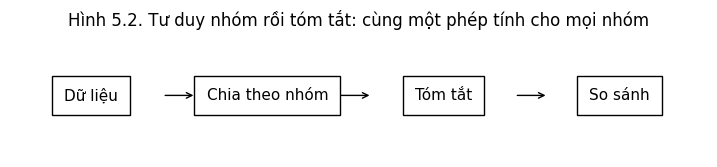

In [28]:
fig, ax = plt.subplots(figsize=(9, 1.6))
ax.axis("off")
cac_buoc = ["Dữ liệu", "Chia theo nhóm", "Tóm tắt", "So sánh"]
for i, buoc in enumerate(cac_buoc):
    ax.text(i * 2.6, 0, buoc, ha="center", va="center", fontsize=11,
            bbox=dict(boxstyle="square,pad=0.8", facecolor="white", edgecolor="black"))
    if i < len(cac_buoc) - 1:
        ax.annotate("", xy=(i * 2.6 + 1.55, 0), xytext=(i * 2.6 + 1.05, 0), arrowprops=dict(arrowstyle="->"))
ax.set_xlim(-1.2, 9.1)
ax.set_ylim(-1, 1)
ax.set_title("Hình 5.2. Tư duy nhóm rồi tóm tắt: cùng một phép tính cho mọi nhóm")
plt.show()

In [29]:
(
    msleep
    .groupby("vore", dropna=False)
    .agg(mean_sleep=("sleep_total", "mean"), n=("sleep_total", "size"))
    .round(2)
)

,mean_sleep,n
vore,,
carni,10.38,19
herbi,9.51,32
insecti,14.94,5
omni,10.92,20
NaN,10.19,7


`dropna=False` giữ lại nhóm có `vore` bị thiếu (7 loài), giống cách STAT 20 trình bày.

> **W03-PY05 ⋆⋆ — Một hàng của kết quả nghĩa là gì?**
> 1. Một hàng của bảng kết quả dưới đây đại diện cho gì?
> 2. Vì sao trung bình của biến logic `gt_8` là một tỉ lệ?
> 3. `n` dùng làm gì khi diễn giải tỉ lệ?

In [30]:
(
    msleep
    .assign(gt_8=msleep["sleep_total"] > 8)
    .groupby("vore", dropna=False)
    .agg(p_gt_8hrs=("gt_8", "mean"), n=("sleep_total", "size"))
    .round(3)
)

,p_gt_8hrs,n
vore,,
carni,0.684,19
herbi,0.594,32
insecti,1.000,5
omni,0.950,20
NaN,0.714,7


<details><summary>Đáp án</summary>

1. Mỗi hàng là một mức của `vore` (kể cả mức thiếu dữ liệu).
2. `True`/`False` được tính là 1/0, nên trung bình là tỉ lệ loài thỏa điều kiện (mục 4.5).
3. `n` giúp không đánh đồng tỉ lệ 100% từ 5 loài ăn côn trùng với một tỉ lệ gần như vậy từ 20 loài ăn tạp.
</details>

> **W03-EX06 ⋆⋆ — Tóm tắt theo nhóm có khớp với biểu đồ?** Tính trung bình hai số đo mỏ theo loài. Trước khi chạy, nhìn lại Hình 1.3 và dự đoán loài nào có `mean_depth` nhỏ nhất.

In [31]:
(
    penguins
    .groupby("species")
    .agg(mean_length=("bill_length_mm", "mean"), mean_depth=("bill_depth_mm", "mean"))
    .round(2)
)

,mean_length,mean_depth
species,,
Adelie,38.79,18.35
Chinstrap,48.83,18.42
Gentoo,47.50,14.98


<details><summary>Đáp án</summary>

Gentoo có độ sâu mỏ trung bình nhỏ nhất (14,98 mm), khớp với cụm điểm Gentoo nằm thấp hơn hẳn trên trục y của Hình 1.3. Đây là một kiểm tra chéo nên làm thường xuyên: nhìn biểu đồ, dự đoán, tính tóm tắt bằng số, rồi diễn giải.
</details>

### 5.4 Từ tỉ lệ có điều kiện tới nghịch lý Simpson

> **W03-EX07 ⋆⋆⋆.** *Tình huống giả định.* Hai thuật toán A và B được đánh giá trên hai loại tác vụ: dễ và khó. "Thành công" nghĩa là hoàn thành tác vụ trong ngưỡng thời gian yêu cầu.
>
> | Độ khó | A: thành công / tổng | B: thành công / tổng |
> |---|---|---|
> | Dễ | 81 / 90 | 19 / 20 |
> | Khó | 1 / 10 | 16 / 80 |
>
> 1. Tính tỉ lệ thành công của A và B trong từng mức độ khó.
> 2. Tính tỉ lệ thành công gộp của A và B.
> 3. Thuật toán nào cao hơn trong từng nhóm? Thuật toán nào cao hơn khi gộp?
> 4. Điều gì tạo ra sự đảo chiều?

Làm bằng tay trước, rồi chạy ô dưới để kiểm tra và vẽ lại.

  thuat_toan do_kho  thanh_cong  tong  ti_le
0          A     Dễ          81    90   0.90
1          A    Khó           1    10   0.10
2          B     Dễ          19    20   0.95
3          B    Khó          16    80   0.20 

            thanh_cong  tong  ti_le_gop
thuat_toan                             
A                   82   100       0.82
B                   35   100       0.35


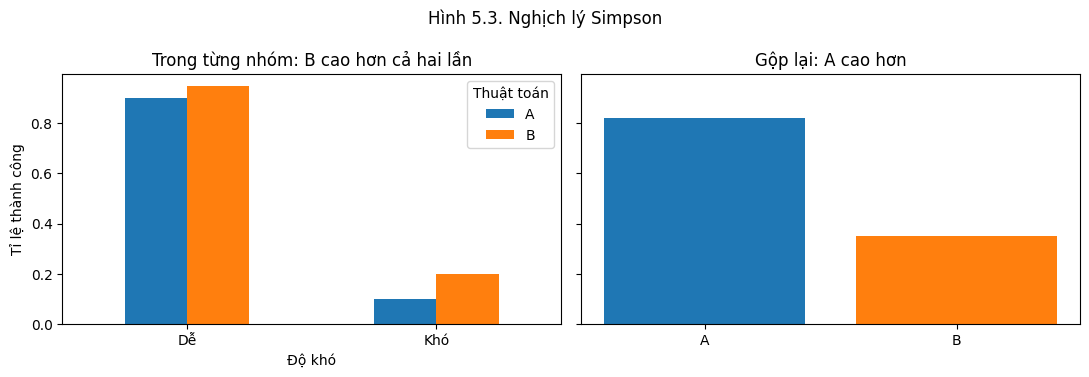

In [32]:
tac_vu = pd.DataFrame({
    "thuat_toan": ["A", "A", "B", "B"],
    "do_kho": ["Dễ", "Khó", "Dễ", "Khó"],
    "thanh_cong": [81, 1, 19, 16],
    "tong": [90, 10, 20, 80],
})
tac_vu["ti_le"] = tac_vu["thanh_cong"] / tac_vu["tong"]
print(tac_vu, "\n")

gop = tac_vu.groupby("thuat_toan")[["thanh_cong", "tong"]].sum()
gop["ti_le_gop"] = gop["thanh_cong"] / gop["tong"]
print(gop)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
bang = tac_vu.pivot(index="do_kho", columns="thuat_toan", values="ti_le")
bang.plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Trong từng nhóm: B cao hơn cả hai lần")
axes[0].set_ylabel("Tỉ lệ thành công")
axes[0].set_xlabel("Độ khó")
axes[0].legend(title="Thuật toán")
axes[1].bar(gop.index, gop["ti_le_gop"], color=["tab:blue", "tab:orange"])
axes[1].set_title("Gộp lại: A cao hơn")
plt.suptitle("Hình 5.3. Nghịch lý Simpson")
plt.tight_layout()
plt.show()

<details><summary>Đáp án</summary>

1. Dễ: A 81/90 = 90%, B 19/20 = 95%. Khó: A 1/10 = 10%, B 16/80 = 20%. B cao hơn trong cả hai nhóm.
2. Gộp: A 82/100 = 82%, B 35/100 = 35%.
3. B cao hơn trong từng nhóm, nhưng A cao hơn khi gộp.
4. Đây là một dạng **nghịch lý Simpson**: thứ tự của mối liên hệ đảo chiều khi chuyển giữa tóm tắt biên và tóm tắt có điều kiện. Nguyên nhân nằm ở mục dưới.
</details>

**Vì sao lại đảo chiều? Cơ chế trọng số.** Tỉ lệ gộp là trung bình có trọng số của các tỉ lệ trong nhóm, với trọng số là phần tác vụ thuộc mỗi nhóm:

$$
\text{A: } 0{,}90 \times 0{,}90 + 0{,}10 \times 0{,}10 = 0{,}82, \qquad
\text{B: } 0{,}20 \times 0{,}95 + 0{,}80 \times 0{,}20 = 0{,}35.
$$

A được giao 90% tác vụ dễ, B nhận 80% tác vụ khó. Khác biệt về cơ cấu nhóm lấn át so sánh trong từng nhóm. Không biết cơ chế phân công tác vụ thì ví dụ này không cho phép kết luận nhân quả rằng thuật toán nào "tốt hơn".

### 5.5 Cùng số liệu, khác ấn tượng

> **W03-EX08 ⋆⋆.** *Tình huống giả định.* Độ trễ trung bình của một hệ thống tăng từ 100 ms lên 104 ms. (1) Hai hình dưới dùng cùng số liệu hay khác số liệu? (2) Vì sao hình bên phải làm mức tăng trông lớn hơn nhiều? (3) Đề xuất cách trình bày trung thực hơn cho câu hỏi "độ trễ tăng bao nhiêu?".

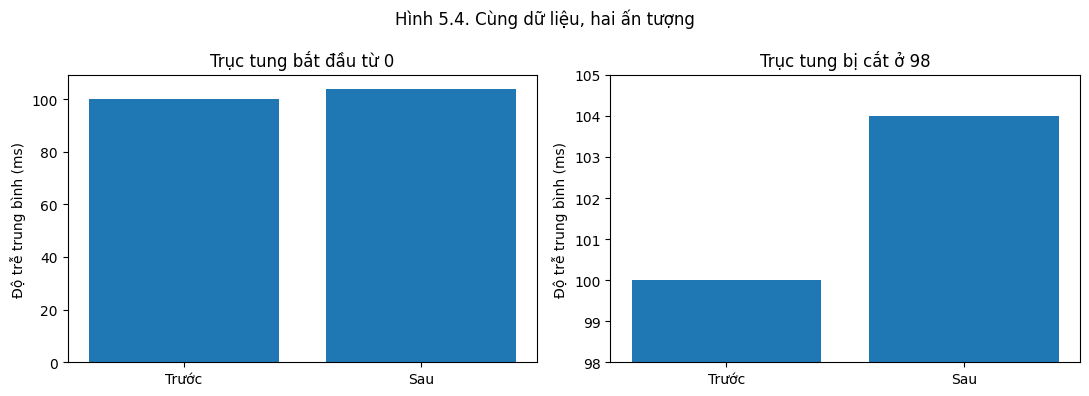

In [33]:
nhan = ["Trước", "Sau"]
do_tre = [100, 104]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(nhan, do_tre)
axes[0].set_title("Trục tung bắt đầu từ 0")
axes[1].bar(nhan, do_tre)
axes[1].set_ylim(98, 105)
axes[1].set_title("Trục tung bị cắt ở 98")
for ax in axes:
    ax.set_ylabel("Độ trễ trung bình (ms)")
plt.suptitle("Hình 5.4. Cùng dữ liệu, hai ấn tượng")
plt.tight_layout()
plt.show()

<details><summary>Đáp án</summary>

1. Cùng dữ liệu: 100 ms và 104 ms.
2. Biểu đồ cột mã hóa giá trị bằng **chiều dài** cột. Cắt trục ở 98 ms làm chênh lệch 4 ms chiếm phần lớn chiều cao hiển thị: cột "Sau" trông cao gấp ba cột "Trước".
3. Nếu dùng cột, bắt đầu trục từ 0. Hoặc dùng điểm hay đường (vốn mã hóa bằng vị trí nên cắt trục không sai), kèm nhãn trực tiếp "+4 ms, tức +4%".

"Đúng số" chưa đủ để bảo đảm "đúng ấn tượng".
</details>

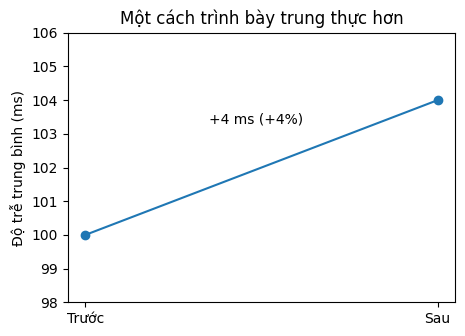

In [34]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(nhan, do_tre, marker="o")
ax.annotate("+4 ms (+4%)", xy=(1, 104), xytext=(0.35, 103.3))
ax.set_ylim(98, 106)
ax.set_ylabel("Độ trễ trung bình (ms)")
ax.set_title("Một cách trình bày trung thực hơn")
plt.show()

---
## Phần 6. Thử thách và tổng kết: điều gì bị tóm tắt gộp che mất?

> **W03-CH02 ⋆⋆⋆ — Một con số đúng nhưng kết luận yếu.** Trong 342 con chim cánh cụt có khối lượng được ghi lại, 172 con nặng trên 4000 g, tức khoảng 50,3%. *Tình huống giả định:* một báo cáo viết "Khoảng một nửa chim cánh cụt vượt 4000 g; vì vậy loài không giúp ta hiểu nhiều về khả năng một cá thể vượt ngưỡng này." Kết luận này có được tỉ lệ gộp 50,3% hỗ trợ không? Bạn sẽ điều kiện hóa theo biến nào để kiểm tra?

In [35]:
co_khoi_luong = penguins.dropna(subset=["body_mass_g"])
print("Tỉ lệ gộp:", round((co_khoi_luong["body_mass_g"] > 4000).mean(), 3))
(
    co_khoi_luong
    .assign(tren_4000=co_khoi_luong["body_mass_g"] > 4000)
    .groupby("species")
    .agg(tren_4000g=("tren_4000", "sum"), so_co_du_lieu=("tren_4000", "size"), ti_le=("tren_4000", "mean"))
    .round(3)
)

Tỉ lệ gộp: 0.503


,tren_4000g,so_co_du_lieu,ti_le
species,,,
Adelie,35,151,0.232
Chinstrap,15,68,0.221
Gentoo,122,123,0.992


<details><summary>Đáp án</summary>

Không. Điều kiện hóa theo `species`: Adelie 35/151 ≈ 23,2%, Chinstrap 15/68 ≈ 22,1%, Gentoo 122/123 ≈ 99,2%. Con số gộp 50,3% che mất một cấu trúc rất mạnh giữa các loài: biết một con là Gentoo gần như chắc chắn nó nặng trên 4000 g.

Điều kiện hóa không "sửa số liệu"; nó đổi câu hỏi từ toàn bộ dữ liệu sang từng nhóm.
</details>

> **W03-CH03 ⋆⋆⋆ — Tự dựng một nghịch lý Simpson.** Xây một bảng 2 × 2 × 2 với hai phương án A, B; hai nhóm $Z = 1, 2$; kết quả thành công / không thành công, sao cho B có tỉ lệ thành công cao hơn A **trong cả hai nhóm**, nhưng A cao hơn B **khi gộp**. Không có số liệu cho sẵn. Giải thích cơ chế trọng số.

Điền bảng của bạn vào ô dưới và chạy để kiểm tra.

In [36]:
# Thay các số dưới đây bằng bảng của bạn: (thành công, tổng)
bang_cua_ban = {
    ("A", "Dễ"): (36, 40), ("A", "Khó"): (1, 10),
    ("B", "Dễ"): (19, 20), ("B", "Khó"): (12, 50),
}
for nhom in ["Dễ", "Khó"]:
    tA = bang_cua_ban[("A", nhom)][0] / bang_cua_ban[("A", nhom)][1]
    tB = bang_cua_ban[("B", nhom)][0] / bang_cua_ban[("B", nhom)][1]
    print(f"{nhom}: A = {tA:.1%}, B = {tB:.1%}  -> B cao hơn? {tB > tA}")
for pa in ["A", "B"]:
    tc = sum(bang_cua_ban[(pa, nh)][0] for nh in ["Dễ", "Khó"])
    tg = sum(bang_cua_ban[(pa, nh)][1] for nh in ["Dễ", "Khó"])
    print(f"Gộp {pa}: {tc}/{tg} = {tc / tg:.1%}")

Dễ: A = 90.0%, B = 95.0%  -> B cao hơn? True
Khó: A = 10.0%, B = 24.0%  -> B cao hơn? True
Gộp A: 37/50 = 74.0%
Gộp B: 31/70 = 44.3%


<details><summary>Một cách dựng</summary>

Chiến lược: (1) chọn một nhóm có tỉ lệ thành công cao ("dễ") và một nhóm có tỉ lệ thấp ("khó"); (2) trong mỗi nhóm, đặt B nhỉnh hơn A; (3) cho A nhận phần lớn quan sát từ nhóm dễ, B nhận phần lớn từ nhóm khó.

Một nghiệm (đang có sẵn trong ô code): Dễ: A 36/40 = 90%, B 19/20 = 95%. Khó: A 1/10 = 10%, B 12/50 = 24%. Trong từng nhóm B cao hơn. Gộp: A 37/50 = 74%, B 31/70 ≈ 44,3%.

Cơ chế: A có trọng số lớn ở nhóm dễ (40/50), B có trọng số lớn ở nhóm khó (50/70).
</details>

> **W03-CH04 ⋆⋆⋆ — Nhóm ẩn có thể đảo cách ta đọc biểu đồ.** *Tình huống giả định.* Mỗi điểm là một lần đo máy chủ; x là mức tải, y là thông lượng. Nhìn gộp, tải cao dường như đi cùng thông lượng cao. (1) Đề xuất một biến thứ ba hợp lý có thể giải thích mẫu hình này. (2) Có thể xảy ra chuyện trong từng nhóm, tải tăng lại đi cùng thông lượng giảm không?

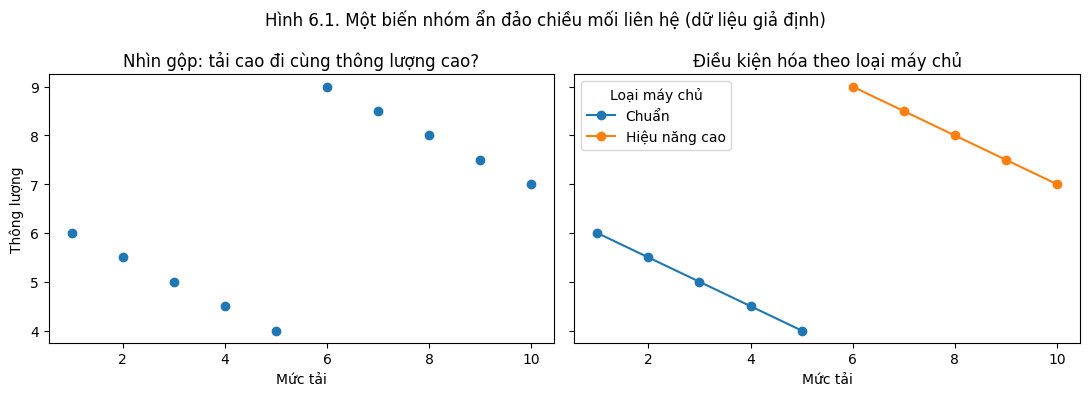

In [37]:
may_chu = pd.DataFrame({
    "tai": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "thong_luong": [6, 5.5, 5, 4.5, 4, 9, 8.5, 8, 7.5, 7],
    "loai_may": ["Chuẩn"] * 5 + ["Hiệu năng cao"] * 5,
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].scatter(may_chu["tai"], may_chu["thong_luong"], color="tab:blue")
axes[0].set_title("Nhìn gộp: tải cao đi cùng thông lượng cao?")
for loai, nhom in may_chu.groupby("loai_may"):
    axes[1].plot(nhom["tai"], nhom["thong_luong"], marker="o", label=loai)
axes[1].set_title("Điều kiện hóa theo loại máy chủ")
axes[1].legend(title="Loại máy chủ")
for ax in axes:
    ax.set_xlabel("Mức tải")
axes[0].set_ylabel("Thông lượng")
plt.suptitle("Hình 6.1. Một biến nhóm ẩn đảo chiều mối liên hệ (dữ liệu giả định)")
plt.tight_layout()
plt.show()

<details><summary>Đáp án</summary>

1. Loại máy chủ. Máy hiệu năng cao thường vừa được giao tải cao hơn vừa có thông lượng cao hơn.
2. Có. Trong từng loại máy, thông lượng giảm khi tải tăng (Hình 6.1, phải). Biểu đồ gộp trộn khác biệt *giữa* các loại máy với thay đổi theo tải *trong* cùng loại máy.

Luôn hỏi: mối liên hệ đang được nhìn ở mức biên hay trong từng nhóm?
</details>

> **W03-CH05 ⋆⋆⋆ — Bác bỏ hai suy luận quá mạnh.** Đánh giá hai khẳng định:
> (A) "Nếu một mối liên hệ xuất hiện trong toàn bộ dữ liệu, nó phải xuất hiện cùng chiều trong mọi nhóm."
> (B) "Nếu điều kiện hóa theo một biến làm mối liên hệ rõ hơn, ta đã chứng minh được quan hệ nhân quả."

<details><summary>Đáp án</summary>

(A) Sai. W03-EX07 là phản ví dụ trực tiếp: B cao hơn trong cả hai nhóm nhưng thấp hơn khi gộp. Hình 6.1 là một phản ví dụ khác với hai biến số.

(B) Sai. Điều kiện hóa có thể gỡ bớt một nguồn trộn lẫn do một biến *đã đo*, nhưng vẫn có thể còn biến ẩn chưa đo, cách hình thành các nhóm có thể mang tính chọn lọc, và dữ liệu quan sát không tự tạo ra so sánh phản thực. Điều kiện hóa giúp mô tả cấu trúc tốt hơn; nó không tự biến một mối liên hệ thành tác động nhân quả (Tuần 12–13).
</details>

### 6.1 Tình huống tổng hợp

> **W03-CASE01 ⋆⋆⋆ — Từ câu hỏi tới biểu đồ và tóm tắt.** *Tình huống giả định dựa trên dữ liệu penguins:* một nhóm phân tích muốn tập trung vào các cá thể **không thuộc Adelie** và có **`bill_length_mm` từ 40 đến 50 mm** (tính cả hai đầu). Sau khi lọc, họ muốn (1) so sánh `bill_length_mm` và `bill_depth_mm` giữa các loài còn lại; (2) vẽ biểu đồ hai số đo mỏ, tô màu theo loài; (3) giải thích vì sao chỉ nhìn trung bình chiều dài mỏ có thể bỏ lỡ một khác biệt quan trọng. Hãy thiết kế chuỗi phân tích; ưu tiên đúng logic hơn đúng cú pháp.

Tự viết thiết kế của bạn trước. Các ô dưới là một lời giải.

In [38]:
# Bước 1: lọc (điều kiện hóa)
subset = penguins.query("species != 'Adelie' and 40 <= bill_length_mm <= 50")

# Bước 2: tóm tắt theo nhóm
(
    subset
    .groupby("species")
    .agg(n=("bill_length_mm", "size"),
         mean_length=("bill_length_mm", "mean"),
         mean_depth=("bill_depth_mm", "mean"))
    .round(2)
)

,n,mean_length,mean_depth
species,,,
Chinstrap,38,46.52,17.82
Gentoo,101,46.52,14.78


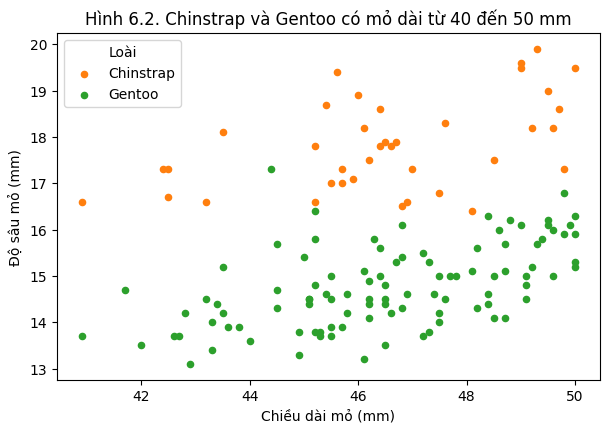

In [39]:
# Bước 3: quay lại biểu đồ
fig, ax = plt.subplots(figsize=(7, 4.5))
for loai, nhom in subset.groupby("species"):
    ax.scatter(nhom["bill_length_mm"], nhom["bill_depth_mm"], label=loai, color=MAU_LOAI[loai], s=20)
ax.set(xlabel="Chiều dài mỏ (mm)", ylabel="Độ sâu mỏ (mm)")
ax.legend(title="Loài")
ax.set_title("Hình 6.2. Chinstrap và Gentoo có mỏ dài từ 40 đến 50 mm")
plt.show()

<details><summary>Đọc kết quả</summary>

Sau khi lọc còn 38 con Chinstrap và 101 con Gentoo. Hai nhóm có **cùng** trung bình chiều dài mỏ, 46,52 mm, trùng tới hai chữ số thập phân. Nếu chỉ báo cáo con số đó, người đọc sẽ nghĩ hai loài có mỏ giống nhau. Nhưng độ sâu mỏ khác rõ (17,82 so với 14,78 mm), và Hình 6.2 cho thấy hai đám mây điểm tách hẳn nhau theo trục y.

Tóm tắt bằng số và biểu đồ nên kiểm tra chéo lẫn nhau, không thay thế nhau.
</details>

---
## Tổng kết

**Những điều mang theo sau Tuần 03**

- Một biểu đồ phân tích được thành dữ liệu, ánh xạ thuộc tính hình ảnh, và dạng hình học; nhóm hoặc facet đưa thêm một biến phân nhóm vào.
- Ánh xạ cho biết biến nào điều khiển một đặc trưng trực quan; thiết lập chỉ đặt một giá trị hiển thị cố định.
- Dạng hình học không chỉ là phong cách: nó quyết định điều gì được nhấn mạnh và phải phù hợp với đơn vị quan sát. Một hình đúng số vẫn có thể gây ấn tượng sai.
- Lọc giữ các hàng thỏa điều kiện; nhóm thay đổi cách phép tóm tắt tiếp theo được áp dụng. Trung bình của một điều kiện logic là một tỉ lệ.
- Một pipeline tốt đọc được như một lập luận. Thứ tự các bước có thể đổi câu hỏi mà code trả lời.
- Tóm tắt biên và tóm tắt có điều kiện có thể cho kết luận rất khác; nghịch lý Simpson là trường hợp đảo chiều cực đoan, sinh ra từ khác biệt về trọng số giữa các nhóm.
- Điều kiện hóa làm lộ cấu trúc bị trộn lẫn, nhưng không tự động chứng minh nhân quả.

**Tự kiểm tra.** Bạn đã giải thích được bằng lời một phân tích đi từ câu hỏi, qua dữ liệu, lọc hoặc nhóm, tóm tắt, ánh xạ, dạng hình học, tới diễn giải chưa? Với một đoạn code bất kỳ, hãy hỏi: mỗi dòng đang thay đổi dữ liệu, biểu đồ, hay câu hỏi?

**Chuẩn bị cho Tuần 04.** Tuần tới chuyển từ "biểu diễn và chia dữ liệu thế nào" sang "**hai hay nhiều biến số liên hệ với nhau thế nào**": biểu đồ phân tán như công cụ mô tả quan hệ số, hệ số tương quan, hồi quy tuyến tính đơn giản, hồi quy tuyến tính đa biến và cách diễn giải hệ số. Hình 1.7 và Hình 6.1 đã cho thấy trước một cái bẫy sẽ gặp lại: một đường thẳng chung có thể che mất cấu trúc nhóm.

---
*Nguồn: STAT 20 (UC Berkeley), bản dịch tiếng Việt, §2.6–2.8; OpenIntro Statistics 4e, Chương 2 (biểu đồ hộp số câu lạc bộ); Introduction to Modern Statistics 2e, Chương 4–5. Dữ liệu: Palmer penguins (Gorman và cộng sự, 2014); `arbuthnot` (gói R `openintro`); `msleep` (gói R `ggplot2`, theo Savage & West, 2007). Dữ liệu ở Hình 1.9 là mô phỏng; bảng ở W03-EX07, W03-CH03, W03-EX08 và W03-CH04 là tình huống giả định.*